## Color Visualization Notebook - Test Plots

### Making an RGB Plot

Has 4 strips, Red, Green, Blue, Greyscale, going from zero (black) to full saturation.  

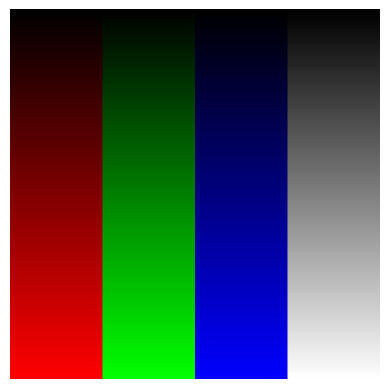

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Create a black image
img = np.zeros((256, 256, 3), dtype=np.uint8)
img = np.ones((256, 256, 3), dtype=np.uint8)
default = 0

# Red gradient (columns 0-63)
for x in range(64):
    for y in range(256):
        img[y, x] = (default,default, y)  # Note: OpenCV uses BGR color format

# Green gradient (columns 64-127)
for x in range(64, 128):
    for y in range(256):
        img[y, x] = (default, y, default)

# Blue gradient (columns 128-191)
for x in range(128, 192):
    for y in range(256):
        img[y, x] = (y, default, default)

# White to black gradient (columns 192-255)
for x in range(192, 256):
    for y in range(256):
        value =  y
        img[y, x] = (value, value, value)

# Display the image
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB format for displaying with matplotlib

# Display the image using matplotlib
plt.imshow(img_rgb)
plt.axis('off') 
plt.show()

### Making a plot of Red axis vs Blue

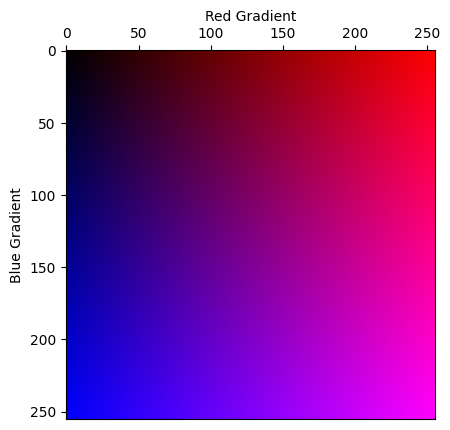

In [2]:
# Create a black image
img = np.zeros((256, 256, 3), dtype=np.uint8)
default = 0

# Combined gradient
for x in range(256):
    for y in range(256):
        img[y, x] = (y, 0, x)  # Setting blue and red simultaneously


# Display the image
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB format for displaying with matplotlib

# Display the image
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

plt.xlabel('Red Gradient')
plt.ylabel('Blue Gradient')

plt.gca().xaxis.set_label_position('top') 
plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

plt.show()

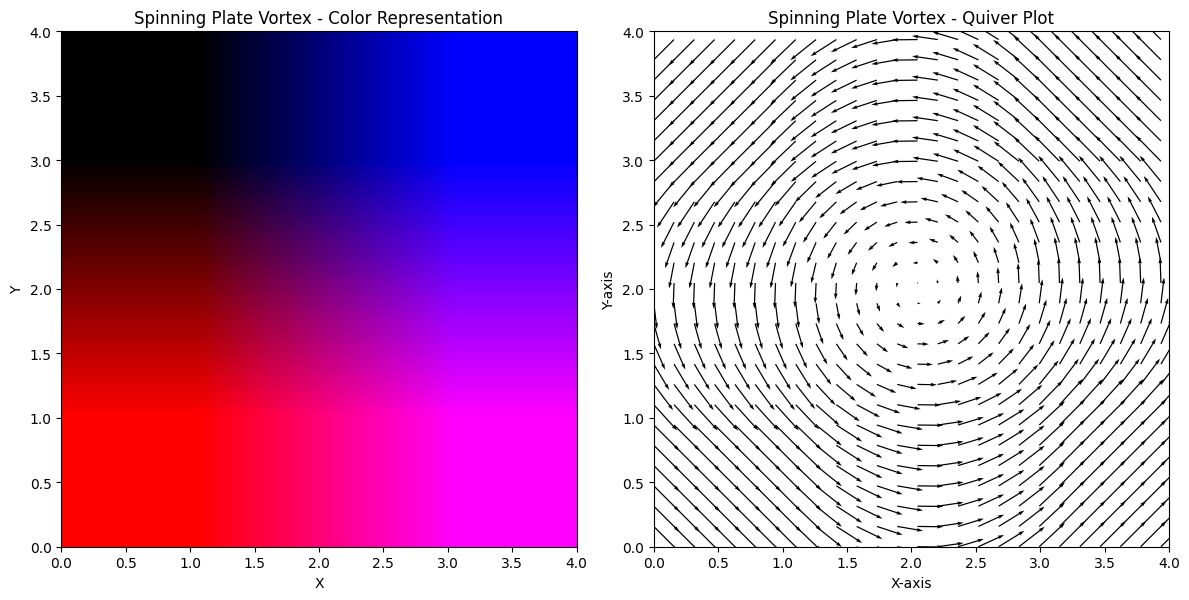

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def vortex_vector_field(x, y, center_x, center_y):
    # Calculate radius and angle
    r = np.sqrt((x - center_x)**2 + (y - center_y)**2) + 1e-8  # small epsilon to prevent divide-by-zero
    theta = np.arctan2(y - center_y, x - center_x)
    
    # Adjusting field components to create a "spinning plate" effect
    u = -r * np.sin(theta) #/ r
    v = r * np.cos(theta) #/ r
    return u, v


# Create a grid of points
x, y = np.meshgrid(np.linspace(0, 4, 255), np.linspace(0, 4, 255))

# Calculate the vector field
center_x, center_y = 2.06, 2.012
u, v = vortex_vector_field(x, y, center_x, center_y)

# Normalize the vector field components to the range [0, 255]
u_normalized = np.clip(((u + 1) / 2) * 255, 0, 255).astype(np.uint8)
v_normalized = np.clip(((v + 1) / 2) * 255, 0, 255).astype(np.uint8)

# Create an RGB image
img = np.zeros((255, 255, 3), dtype=np.uint8)
img[:, :, 0] = u_normalized  # Red channel for horizontal component
img[:, :, 2] = v_normalized  # Blue channel for vertical component

# Create the quiver plot
max_val = 1  # Adjust as needed
u_clipped = np.clip(u, -max_val, max_val)
v_clipped = np.clip(v, -max_val, max_val)
skip = 10
X_downsampled = x[::skip, ::skip]
Y_downsampled = y[::skip, ::skip]
u_clipped_downsampled = u_clipped[::skip, ::skip]
v_clipped_downsampled = v_clipped[::skip, ::skip]


# Display the image in the first subplot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns

axes[0].imshow(img, origin='lower', extent=[0, 4, 0, 4])
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].set_title('Spinning Plate Vortex - Color Representation')

# Plot the quiver plot in the second subplot
axes[1].quiver(X_downsampled, Y_downsampled, u_clipped_downsampled, v_clipped_downsampled, scale=20, color='black')
axes[1].set_title("Spinning Plate Vortex - Quiver Plot")
axes[1].set_xlim([0, 4])
axes[1].set_ylim([0, 4])
axes[1].set_xlabel("X-axis")
axes[1].set_ylabel("Y-axis")
axes[1].set_aspect('equal')

plt.tight_layout()  # Adjust spacing between subplots
plt.show()


### Making an HSV Plot

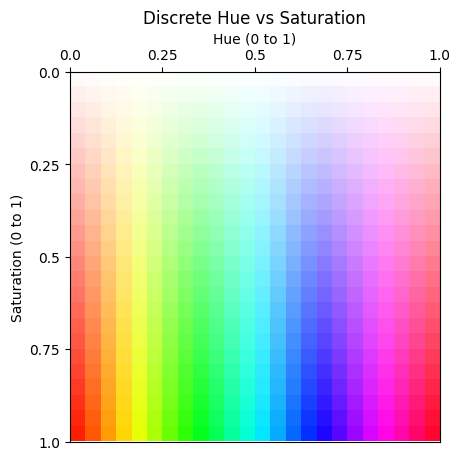

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Set block size for 30x30 grid
block_size = 24

# Create an HSV image with original size
img_hsv = np.zeros((256, 256, 3), dtype=np.uint8)

# Generate Hue and Saturation gradients
for x in range(256):
    for y in range(256):
        hue = int(x * 179 / 255)  # Scale x to 0-179 for hue
        img_hsv[y, x] = (hue, y, 255)  # Set Hue and Saturation
        img_hsv[y, x] = (hue, 255 - y, 255)  # Set Hue and Saturation


# Resize the HSV image to 30x30 blocks
img_hsv_small = cv2.resize(img_hsv, (block_size, block_size), interpolation=cv2.INTER_AREA)

# Convert to RGB for display
img_rgb_small = cv2.cvtColor(img_hsv_small, cv2.COLOR_HSV2RGB)

# Display the discretized image
plt.title('Discrete Hue vs Saturation')
plt.imshow(img_rgb_small, extent=(0, 1, 0, 1), origin='lower')  # Set origin='lower'

# Configure plot labels and ticks
plt.xlabel('Hue (0 to 1)')
plt.ylabel('Saturation (0 to 1)')
plt.gca().xaxis.set_label_position('top')

# Set x and y ticks with finer intervals for more tick marks
num_ticks = 5  # Number of ticks for finer detail
tick_values = np.linspace(0, 1, num_ticks)
plt.xticks(tick_values, np.round(tick_values, 2))
tick_values = np.linspace(0, 1, num_ticks)
plt.yticks(tick_values, np.round(1-tick_values, 2))

# Set tick parameters for appearance
plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

plt.show()


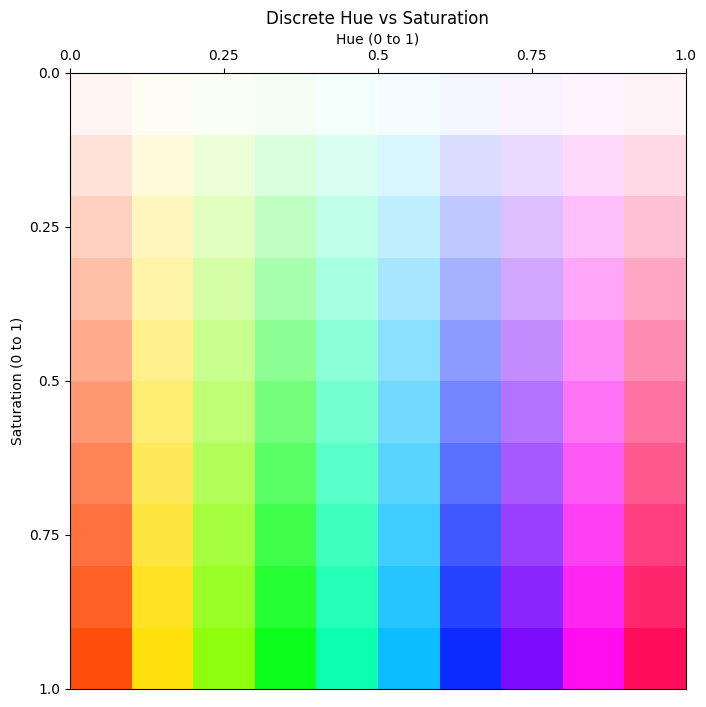

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Set block size for 30x30 grid
block_size = 10

# Create an HSV image with original size
img_hsv = np.zeros((256, 256, 3), dtype=np.uint8)

# Generate Hue and Saturation gradients
for x in range(256):
    for y in range(256):
        hue = int(x * 179 / 255)  # Scale x to 0-179 for hue
        img_hsv[y, x] = (hue, y, 255)  # Set Hue and Saturation
        img_hsv[y, x] = (hue, 255 - y, 255)  # Set Hue and Saturation


# Resize the HSV image to 30x30 blocks
img_hsv_small = cv2.resize(img_hsv, (block_size, block_size), interpolation=cv2.INTER_AREA)

# Convert to RGB for display
img_rgb_small = cv2.cvtColor(img_hsv_small, cv2.COLOR_HSV2RGB)

# Display the discretized image
plt.figure(figsize=(8, 8))
plt.title('Discrete Hue vs Saturation')
plt.imshow(img_rgb_small, extent=(0, 1, 0, 1), origin='lower')  # Set origin='lower'

# Configure plot labels and ticks
plt.xlabel('Hue (0 to 1)')
plt.ylabel('Saturation (0 to 1)')
plt.gca().xaxis.set_label_position('top')

# Set x and y ticks with finer intervals for more tick marks
num_ticks = 5  # Number of ticks for finer detail
tick_values = np.linspace(0, 1, num_ticks)
plt.xticks(tick_values, np.round(tick_values, 2))
tick_values = np.linspace(0, 1, num_ticks)
plt.yticks(tick_values, np.round(1-tick_values, 2))

# Set tick parameters for appearance
plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

plt.show()


## Making A Vortex in RGB Space

R - X vector
B - Y Vector

## RGB Plot with Magnitude Direction Scaling

### Vortex but with HSV

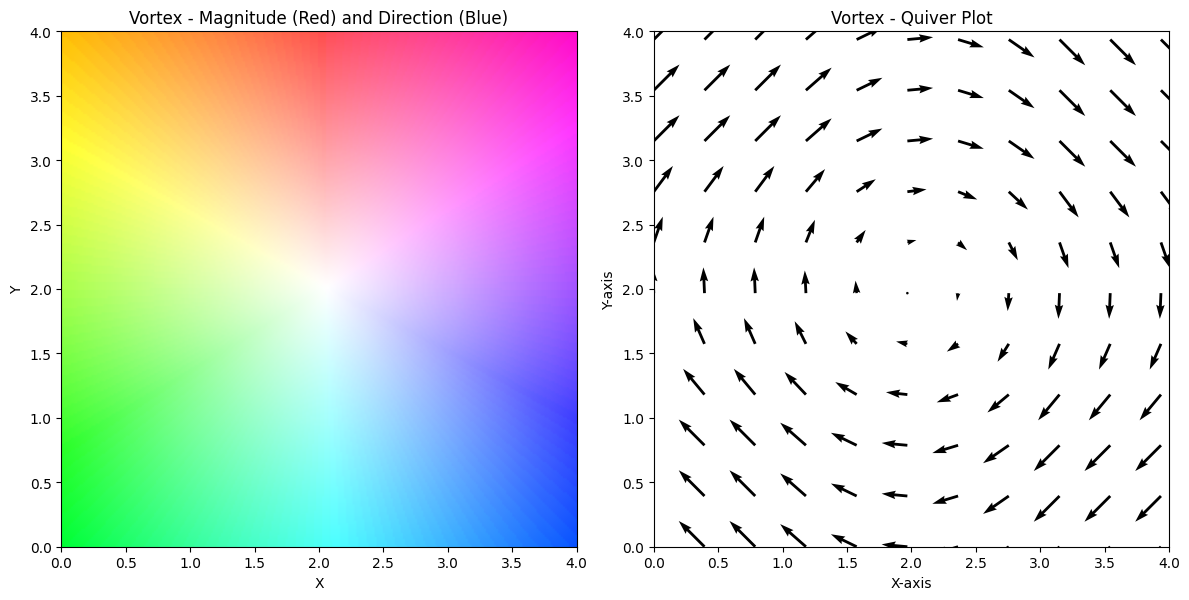

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

def vortex_vector_field(x, y, center_x, center_y):
    # Calculate radius and angle
    r = np.sqrt((x - center_x)**2 + (y - center_y)**2) + 1e-8  # small epsilon to prevent divide-by-zero
    theta = np.arctan2(y - center_y, x - center_x)
    
    # Adjusting field components to create a "spinning plate" effect
    u = -r * np.sin(theta) #/ r
    v = r * np.cos(theta) #/ r
    return u, v

def calculate_magnitude_direction(u, v):
    # Calculate magnitude and direction
    magnitude = np.sqrt(u**2 + v**2)  # Magnitude
    direction = (np.arctan2(v, u) + np.pi) / (2 * np.pi)  # Normalize direction to 0-1
    return magnitude, direction


# Create a grid of points
x, y = np.meshgrid(np.linspace(0, 4, 255), np.linspace(0, 4, 255))

# Calculate the vector field
center_x, center_y = 2.06, 2.012
u, v = vortex_vector_field(x, y, center_x, center_y)

# Calculate magnitude and direction from u and v
magnitude, direction = calculate_magnitude_direction(u, v)

# Normalize magnitude to the range [0, 255] for Saturation
magnitude_normalized = np.clip(magnitude * (255 / np.max(magnitude)), 0, 255).astype(np.uint8)

# Scale direction to the range [0, 179] for Hue (OpenCV range)
direction_scaled = np.clip(direction * 179, 0, 179).astype(np.uint8)

# Create an HSV image
img_hsv = np.zeros((255, 255, 3), dtype=np.uint8)
img_hsv[:, :, 0] = direction_scaled  # Hue channel represents direction
img_hsv[:, :, 1] = magnitude_normalized  # Saturation channel represents magnitude
img_hsv[:, :, 2] = 255  # Set Value to maximum

# Convert HSV to RGB for display
img_rgb = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)

# Create the quiver plot
max_val = 1  # Adjust as needed
u_clipped = np.clip(magnitude * np.cos(direction * 2 * np.pi), -max_val, max_val)  # Use magnitude and direction
v_clipped = np.clip(magnitude * np.sin(direction * 2 * np.pi), -max_val, max_val)  # Use magnitude and direction

# Downsample the grid for the quiver plot (e.g., every 10th point)
skip = 25
X_downsampled = x[::skip, ::skip]
Y_downsampled = y[::skip, ::skip]
u_clipped_downsampled = u_clipped[::skip, ::skip]
v_clipped_downsampled = v_clipped[::skip, ::skip]

# Display the image in the first subplot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns

axes[0].imshow(img_rgb, origin='lower', extent=[0, 4, 0, 4])
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].set_title('Vortex - Magnitude (Red) and Direction (Blue)')

# Plot the quiver plot in the second subplot
axes[1].quiver(X_downsampled, Y_downsampled, u_clipped_downsampled, v_clipped_downsampled, scale=20, color='black')
axes[1].set_title("Vortex - Quiver Plot")
axes[1].set_xlim([0, 4])
axes[1].set_ylim([0, 4])
axes[1].set_xlabel("X-axis")
axes[1].set_ylabel("Y-axis")
axes[1].set_aspect('equal')

plt.tight_layout()  # Adjust spacing between subplots
plt.show()

Is this the same as above, but clipped? Did I already do the work?

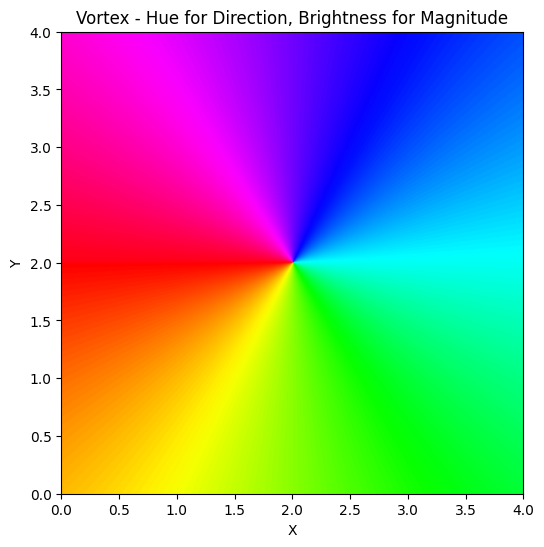

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def vortex_vector_field(x, y, center_x, center_y):
    # Calculate radius and angle for vortex field
    r = np.sqrt((x - center_x)**2 + (y - center_y)**2) + 1e-5
    theta = np.arctan2(y - center_y, x - center_x)
    return r, theta

# Set up grid and vortex center
center_x, center_y = 2.005, 2.0012
x, y = np.meshgrid(np.linspace(0, 4, 1000), np.linspace(0, 4, 1000))

# Calculate field parameters
r, theta = vortex_vector_field(x, y, center_x, center_y)

# Map theta to hue and r to brightness for RGB representation
hue = (theta + np.pi) / (2 * np.pi)  # Normalize to range [0, 1]
brightness = np.clip(r ** 0.3, 0, 1)  # Use a non-linear brightness transformation

# Convert to RGB using matplotlib's HSV to RGB converter
hsv_image = np.zeros((1000, 1000, 3))
hsv_image[..., 0] = hue                # Hue represents direction
hsv_image[..., 1] = 1                  # Full saturation
hsv_image[..., 2] = brightness         # Brightness represents magnitude
rgb_image = plt.cm.hsv(hsv_image[..., 0])[:, :, :3]


# Display the image
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(rgb_image, origin='lower', extent=[0, 4, 0, 4])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Vortex - Hue for Direction, Brightness for Magnitude')
plt.show()


/var/folders/nh/h2lw4fwd2f36n5kbgnd30wy80000gn/T/ipykernel_47806/1082153833.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


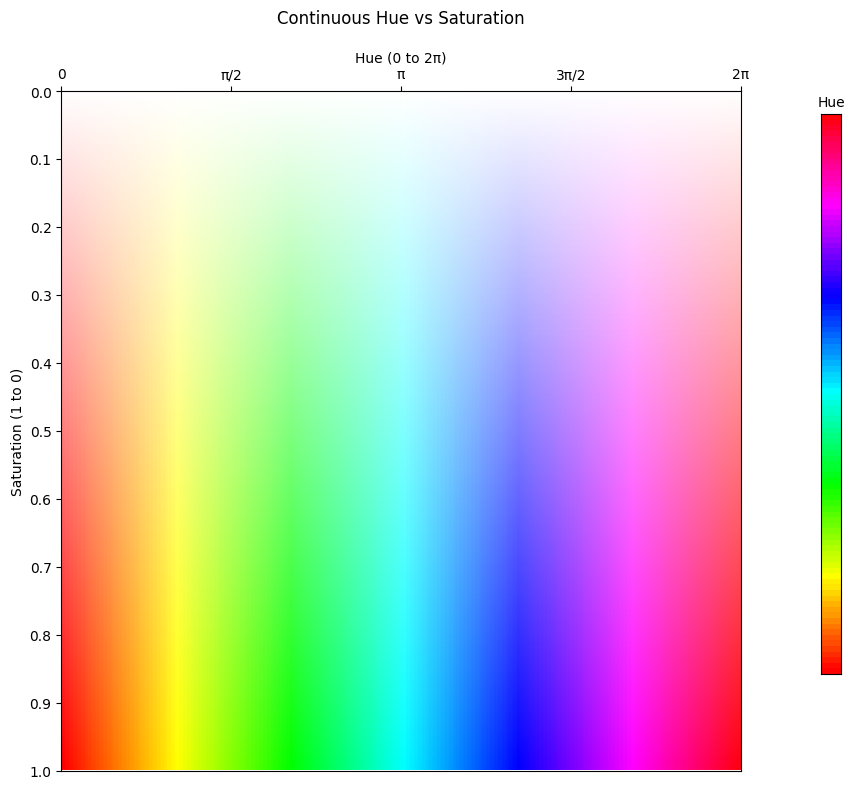

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import math

# Create a high-resolution image for continuous appearance
img_size = 512  # Use a larger size for smoother gradients

# Create an HSV image
img_hsv = np.zeros((img_size, img_size, 3), dtype=np.uint8)

# Generate continuous Hue and Saturation gradients
for x in range(img_size):
    for y in range(img_size):
        hue = int(x * 179 / (img_size-1))  # Scale x to 0-179 for hue (OpenCV HSV format)
        saturation = 255 - int(y * 255 / (img_size-1))  # Invert y for saturation
        img_hsv[y, x] = (hue, saturation, 255)  # Set Hue, Saturation, and Value

# Convert HSV to RGB for display
img_rgb = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)

# Create the plot
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb, extent=(0, 1, 0, 1), origin='lower')

# Configure plot labels
plt.title('Continuous Hue vs Saturation', pad=20)
plt.xlabel('Hue (0 to 2π)')
plt.ylabel('Saturation (1 to 0)')

# Custom formatter function for hue (x-axis) to display in terms of π
def hue_formatter(x, pos):
    if x == 0:
        return "0"
    elif x == 0.25:
        return "π/2"
    elif x == 0.5:
        return "π"
    elif x == 0.75:
        return "3π/2"
    elif x == 1:
        return "2π"
    else:
        return f"{x*2*math.pi:.2f}"

# Custom formatter for saturation (y-axis) to invert the labels
def sat_formatter(y, pos):
    return f"{1-y:.1f}"

# Set x and y ticks with custom formatting
plt.gca().xaxis.set_major_formatter(FuncFormatter(hue_formatter))
plt.gca().yaxis.set_major_formatter(FuncFormatter(sat_formatter))

# Set tick positions
x_ticks = [0, 0.25, 0.5, 0.75, 1.0]
y_ticks = np.linspace(0, 1, 11)  # 0, 0.1, 0.2, ..., 1.0
plt.xticks(x_ticks)
plt.yticks(y_ticks)

# Move x-axis labels to top
plt.gca().xaxis.set_label_position('top')
plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

# Add a colorbar for reference
cbar_ax = plt.axes([0.92, 0.15, 0.02, 0.7])
hue_gradient = np.zeros((100, 1, 3), dtype=np.uint8)
for i in range(100):
    hue_gradient[i, 0] = (int(i*179/99), 255, 255)
hue_gradient_rgb = cv2.cvtColor(hue_gradient, cv2.COLOR_HSV2RGB)
plt.imshow(hue_gradient_rgb, aspect='auto', extent=(0, 1, 0, 1), origin='lower')
plt.title('Hue', fontsize=10)
plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.show()